<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/09_torque_target_and_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [5]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

# ============================================================
# LOAD ORDER-001 (added after initiating 06_bseline_feature_generation.ipynb)
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

# ============================================================
# LOAD FEAT-001 — REQUIRED FROM NOTEBOOK 07 ONWARD
# ============================================================

FEATURE_CONFIG_PATH = (
    CONFIG_DIR
    / "features_v001.yaml"
)

if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Required FEAT-001 configuration "
        "is missing:\n"
        f"{FEATURE_CONFIG_PATH}"
    )


try:

    with open(
        FEATURE_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        feature_config = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "FEAT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


FEATURE_VERSION = (
    feature_config[
        "specification"
    ]["feature_version"]
)

assert FEATURE_VERSION == "FEAT-001", (
    f"Expected FEAT-001, "
    f"found {FEATURE_VERSION}"
)


# ------------------------------------------------------------
# Load persistent FEAT-001 feature table
# ------------------------------------------------------------

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)

if not BASELINE_FEATURE_PATH.exists():

    raise FileNotFoundError(
        "Required FEAT-001 feature table "
        "is missing:\n"
        f"{BASELINE_FEATURE_PATH}"
    )


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


# ------------------------------------------------------------
# Validate frozen feature table
# ------------------------------------------------------------

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert (
    baseline_features[
        "sample_id"
    ].notna().all()
)

assert set(
    baseline_features[
        "feature_version"
    ].unique()
) == {
    "FEAT-001"
}

assert set(
    baseline_features[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

assert (
    len(baseline_features)
    ==
    len(sample_manifest)
)

assert set(
    baseline_features[
        "sample_id"
    ]
) == set(
    sample_manifest[
        "sample_id"
    ]
)


print(
    f"LOADED baseline_features: "
    f"{baseline_features.shape}"
)

print(
    f"Feature version: "
    f"{FEATURE_VERSION}"
)

print(
    "PASS: FEAT-001 restored and validated."
)

# ------------------------------------------------------------
# Updating Readiness Summary
# ------------------------------------------------------------
print()
print("=" * 68)
print("MODELING ENVIRONMENT READY")
print("=" * 68)

print(
    f"Preprocessing:       "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:       "
    f"{SPLIT_VERSION}"
)

print(
    f"Order analysis:      "
    f"{ORDER_ANALYSIS_VERSION}"
)

print(
    f"Feature definition:  "
    f"{FEATURE_VERSION}"
)

print(
    f"Sample manifest:     "
    f"{len(sample_manifest):,} samples"
)

print(
    f"Feature table:       "
    f"{len(baseline_features):,} samples"
)

print(
    f"Feature columns:     "
    f"{baseline_features.shape[1]}"
)

print("=" * 68)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

In [6]:
# Step 64 — Begin the torque modeling phase
# Do not jump straight into a multi-task neural network.
# We first need to answer:
# Is torque actually well represented across our frozen train/validation/test
# populations, and how difficult is torque prediction using the conventional
# FEAT-001 representation?

# Step 64.1 — Load the torque modeling population

# ============================================================
# STEP 64.1 — LOAD TORQUE MODELING POPULATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

SAMPLE_MANIFEST_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "sample_manifest_v001.csv"
)


if not SAMPLE_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Sample manifest missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


required_columns = [
    "sample_id",
    "parent_file_id",
    "split",
    "rpm_mean",
    "torque_mean_nm",
    "model_eligible_rpm_v001",
]


missing_columns = [
    column
    for column in required_columns
    if column not in sample_manifest.columns
]


if missing_columns:
    raise RuntimeError(
        "Required columns missing:\n"
        +
        "\n".join(
            missing_columns
        )
    )


torque_population = (
    sample_manifest.loc[
        (
            sample_manifest[
                "model_eligible_rpm_v001"
            ] == True
        )
        &
        (
            sample_manifest[
                "torque_mean_nm"
            ].notna()
        )
    ]
    .copy()
)


print(
    f"Total manifest windows: "
    f"{len(sample_manifest):,}"
)

print(
    f"Candidate torque windows: "
    f"{len(torque_population):,}"
)

print()

print(
    torque_population[
        "split"
    ].value_counts()
)

Total manifest windows: 16,503
Candidate torque windows: 11,646

split
train         7958
test          1890
validation    1798
Name: count, dtype: int64


In [7]:
# Step 64.2 — Inspect available torque-related metadata
# Don't assume which torque-variation fields exist. Discover them first.

# ============================================================
# STEP 64.2 — INSPECT TORQUE METADATA
# ============================================================

torque_columns = [
    column
    for column
    in sample_manifest.columns
    if "torque" in column.lower()
]


print(
    "Torque-related manifest columns:"
)

for column in torque_columns:
    print(
        " -",
        column
    )

Torque-related manifest columns:
 - torque_mean_nm
 - torque_median_nm
 - torque_min_nm
 - torque_max_nm
 - torque_std_nm
 - torque_range_nm


In [8]:
# Step 64.3 — Audit torque distribution by split

# ============================================================
# STEP 64.3 — TORQUE DISTRIBUTION AUDIT
# ============================================================

torque_summary = (
    torque_population
    .groupby(
        "split"
    )[
        "torque_mean_nm"
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max",
        ]
    )
)


display(
    torque_summary
)


torque_quantiles = (
    torque_population
    .groupby(
        "split"
    )[
        "torque_mean_nm"
    ]
    .quantile(
        [
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .unstack()
)


display(
    torque_quantiles
)

,count,mean,std,min,median,max
split,,,,,,
test,1890,110.260337,176.055747,-107.025146,32.347866,698.306301
train,7958,105.105206,170.335070,-106.980342,33.963058,704.066985
validation,1798,105.663266,185.066470,-105.837465,51.618415,697.622404


,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
split,,,,,,,,,
test,-100.842348,-79.446728,-62.580781,-24.386096,32.347866,212.943689,338.149141,453.723129,692.322255
train,-100.306397,-81.531144,-71.099575,-20.751953,33.963058,178.791809,341.358987,452.986619,686.539915
validation,-102.278636,-91.065144,-77.973256,-29.403080,51.618415,181.704936,334.785100,429.460847,695.507755


In [9]:
# Step 64.4 — Examine RPM–torque relationship
# This is important for multi-task learning because we need to know whether
# torque supplies genuinely additional information or is almost
# deterministically tied to RPM.

# ============================================================
# STEP 64.4 — RPM / TORQUE RELATIONSHIP
# ============================================================

correlation = (
    torque_population[
        [
            "rpm_mean",
            "torque_mean_nm",
        ]
    ]
    .corr()
    .loc[
        "rpm_mean",
        "torque_mean_nm",
    ]
)


print(
    f"RPM / torque Pearson correlation: "
    f"{correlation:.4f}"
)


RPM / torque Pearson correlation: 0.2372


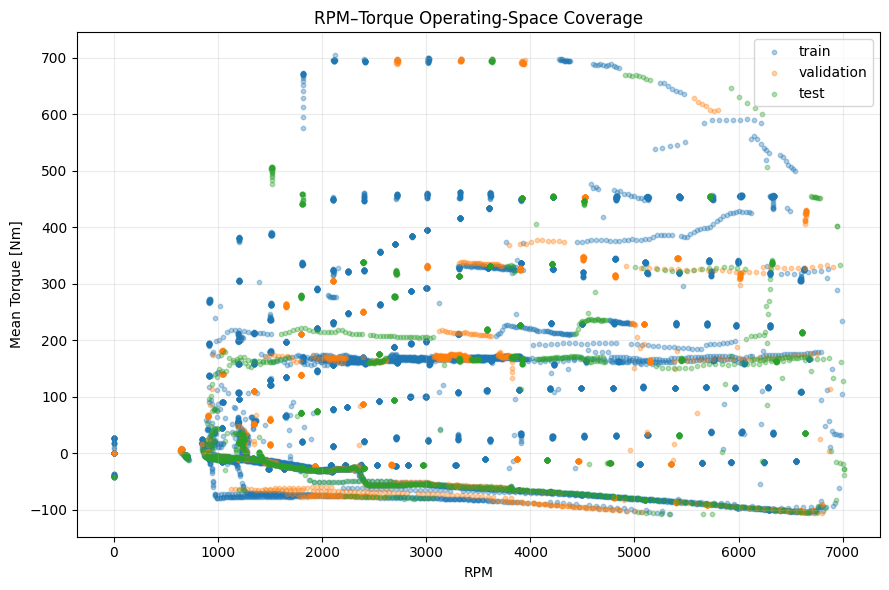

In [10]:
# ..Plot

# ============================================================
# STEP 64.5 — RPM VS TORQUE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt


TORQUE_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "torque"
)

TORQUE_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


for split_name in [
    "train",
    "validation",
    "test",
]:

    split_data = (
        torque_population.loc[
            torque_population[
                "split"
            ] == split_name
        ]
    )

    ax.scatter(
        split_data[
            "rpm_mean"
        ],
        split_data[
            "torque_mean_nm"
        ],
        s=10,
        alpha=0.35,
        label=split_name,
    )


ax.set_xlabel(
    "RPM"
)

ax.set_ylabel(
    "Mean Torque [Nm]"
)

ax.set_title(
    "RPM–Torque Operating-Space Coverage"
)

ax.legend()

ax.grid(
    True,
    alpha=0.25,
)

fig.tight_layout()


RPM_TORQUE_FIGURE_PATH = (
    TORQUE_FIGURE_DIR
    / "01_rpm_torque_split_coverage.png"
)


fig.savefig(
    RPM_TORQUE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(fig)

In [11]:
# Step 64.6 — Save the torque audit tables

# ============================================================
# STEP 64.6 — SAVE TORQUE AUDIT TABLES
# ============================================================

TORQUE_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
)

TORQUE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TORQUE_SUMMARY_PATH = (
    TORQUE_TABLE_DIR
    / "torque_distribution_by_split_v001.csv"
)

TORQUE_QUANTILES_PATH = (
    TORQUE_TABLE_DIR
    / "torque_quantiles_by_split_v001.csv"
)


torque_summary.to_csv(
    TORQUE_SUMMARY_PATH
)

torque_quantiles.to_csv(
    TORQUE_QUANTILES_PATH
)


print(
    f"Saved:\n"
    f"{TORQUE_SUMMARY_PATH}"
)

print()

print(
    f"Saved:\n"
    f"{TORQUE_QUANTILES_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/torque_distribution_by_split_v001.csv

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/torque_quantiles_by_split_v001.csv


Observations from Torque data audit

Three things stand out. First, the train/validation/test torque distributions are reasonably comparable at the aggregate level: means are ~105–110 Nm and the broad quantiles overlap. Second, torque is clearly multimodal, spanning roughly −107 to +704 Nm with distinct operating branches rather than one simple RPM–torque curve. Third, the RPM–torque Pearson correlation of only 0.2372 is encouraging: torque is not just a trivial proxy for RPM. That makes the eventual RPM+torque multi-task experiment scientifically worthwhile.

The operating-space plot also shows substantial split overlap, although some high-torque operating branches are sparse. So I would proceed, but not use the existing RPM eligibility flag blindly. We first freeze a torque-specific steady-state population.

The next progression is:

* Step 65  Freeze TORQUE-SPEC-001
* Step 66  Build torque-ready FEAT-001 table
* Step 67  Train torque conventional baselines
* Step 68  Select frozen torque benchmark
* Step 69  One-time test of selected torque baseline
* Step 70  Freeze torque-baseline phase
* Step 71  Begin MTL-001 specification

Do not touch the CNN test sets from the RPM experiments.

Step 65 — Freeze the first torque modeling specification

For the first torque model, I recommend using windows that are:

1.   already RPM-steady under PREP-001;
2.   have valid torque labels; and
3.   are also torque-steady.

Because torque crosses zero and becomes negative, a purely percentage-based stability criterion is inappropriate. We'll use a hybrid rule analogous to the RPM rule:

torque_range <= max(20 Nm, 5% × |mean torque|)

The 20 Nm floor prevents near-zero torque windows from being rejected for tiny percentage changes, while the 5% term gives higher-torque states slightly more tolerance.

Before freezing it, we'll check what population that rule produces.

In [12]:
# Step 65.1 — Validate torque statistics

# ============================================================
# STEP 65.1 — VALIDATE TORQUE TARGET STATISTICS
# ============================================================

import numpy as np
import pandas as pd

required_torque_columns = [
    "torque_mean_nm",
    "torque_median_nm",
    "torque_min_nm",
    "torque_max_nm",
    "torque_std_nm",
    "torque_range_nm",
]

missing_columns = [
    column
    for column in required_torque_columns
    if column not in sample_manifest.columns
]

if missing_columns:
    raise RuntimeError(
        "Missing torque columns:\n"
        + "\n".join(missing_columns)
    )


torque_check = (
    sample_manifest.loc[
        sample_manifest[
            "torque_mean_nm"
        ].notna()
    ]
    .copy()
)


assert (
    torque_check["torque_range_nm"]
    >= 0
).all()

assert (
    torque_check["torque_std_nm"]
    >= 0
).all()

assert (
    torque_check["torque_min_nm"]
    <= torque_check["torque_mean_nm"]
).all()

assert (
    torque_check["torque_max_nm"]
    >= torque_check["torque_mean_nm"]
).all()


print(
    f"Valid torque windows: "
    f"{len(torque_check):,}"
)

print(
    "PASS: Torque statistics internally consistent."
)

Valid torque windows: 16,503
PASS: Torque statistics internally consistent.


In [13]:
# Step 65.2 — Apply the candidate steady-torque rule

# ============================================================
# STEP 65.2 — CANDIDATE TORQUE STEADY-STATE RULE
# ============================================================

TORQUE_RANGE_FLOOR_NM = 20.0
TORQUE_RANGE_RELATIVE = 0.05


sample_manifest = (
    sample_manifest.copy()
)


sample_manifest[
    "torque_stability_limit_nm_v001"
] = np.maximum(

    TORQUE_RANGE_FLOOR_NM,

    TORQUE_RANGE_RELATIVE
    *
    np.abs(
        sample_manifest[
            "torque_mean_nm"
        ]
    ),
)


sample_manifest[
    "torque_steady_v001"
] = (

    sample_manifest[
        "torque_mean_nm"
    ].notna()

    &

    (
        sample_manifest[
            "torque_range_nm"
        ]
        <=
        sample_manifest[
            "torque_stability_limit_nm_v001"
        ]
    )
)


sample_manifest[
    "model_eligible_torque_v001"
] = (

    sample_manifest[
        "model_eligible_rpm_v001"
    ].astype(bool)

    &

    sample_manifest[
        "torque_steady_v001"
    ]
)


torque_eligibility_summary = (

    sample_manifest

    .groupby(
        "split"
    )

    .agg(

        total_windows=(
            "sample_id",
            "size",
        ),

        rpm_eligible=(
            "model_eligible_rpm_v001",
            "sum",
        ),

        torque_eligible=(
            "model_eligible_torque_v001",
            "sum",
        ),
    )

    .reset_index()
)


torque_eligibility_summary[
    "torque_eligible_pct_of_rpm_population"
] = (

    100
    *
    torque_eligibility_summary[
        "torque_eligible"
    ]
    /
    torque_eligibility_summary[
        "rpm_eligible"
    ]
)


display(
    torque_eligibility_summary
)

,split,total_windows,rpm_eligible,torque_eligible,torque_eligible_pct_of_rpm_population
0,test,2446,1890,1815,96.031746
1,train,11555,7958,7739,97.248052
2,validation,2502,1798,1749,97.274750


In [14]:
# Step 65.3 — Inspect training-only torque-range statistics
# This tells us whether 20 Nm / 5% is behaving sensibly rather than
# throwing away most of the dataset.

# ============================================================
# STEP 65.3 — TORQUE STABILITY DIAGNOSTICS
# ============================================================

training_rpm_eligible = (
    sample_manifest.loc[
        (
            sample_manifest[
                "split"
            ] == "train"
        )
        &
        (
            sample_manifest[
                "model_eligible_rpm_v001"
            ] == True
        )
    ]
    .copy()
)


range_quantiles = (
    training_rpm_eligible[
        "torque_range_nm"
    ]
    .quantile(
        [
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


std_quantiles = (
    training_rpm_eligible[
        "torque_std_nm"
    ]
    .quantile(
        [
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


print(
    "Training torque-range quantiles [Nm]"
)

display(
    range_quantiles.to_frame(
        "torque_range_nm"
    )
)


print(
    "\nTraining torque-std quantiles [Nm]"
)

display(
    std_quantiles.to_frame(
        "torque_std_nm"
    )
)

Training torque-range quantiles [Nm]


,torque_range_nm
0.25,1.525879
0.50,2.746582
0.75,5.645752
0.90,10.803223
0.95,15.502930
0.99,70.337524



Training torque-std quantiles [Nm]


,torque_std_nm
0.25,0.339278
0.50,0.594324
0.75,1.224078
0.90,2.348339
0.95,3.471566
0.99,21.013553


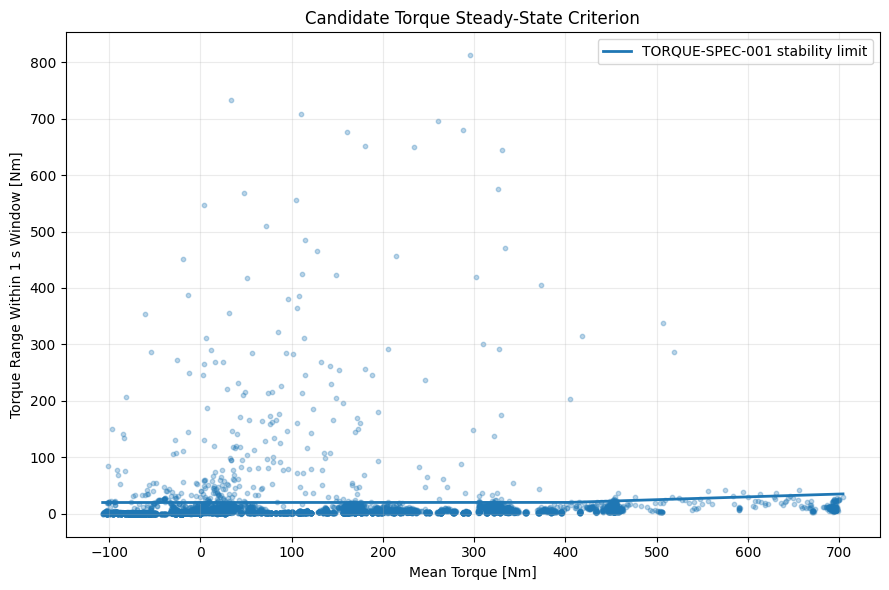

In [15]:
# Step 65.4 — Visualize the proposed stability boundary

# ============================================================
# STEP 65.4 — TORQUE STABILITY RULE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

TORQUE_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "torque"
)

TORQUE_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


plot_data = (
    sample_manifest.loc[
        sample_manifest[
            "model_eligible_rpm_v001"
        ] == True
    ]
    .copy()
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.scatter(
    plot_data[
        "torque_mean_nm"
    ],
    plot_data[
        "torque_range_nm"
    ],
    s=10,
    alpha=0.30,
)


torque_axis = np.linspace(
    plot_data[
        "torque_mean_nm"
    ].min(),
    plot_data[
        "torque_mean_nm"
    ].max(),
    500,
)


limit_axis = np.maximum(
    TORQUE_RANGE_FLOOR_NM,
    TORQUE_RANGE_RELATIVE
    * np.abs(
        torque_axis
    ),
)


ax.plot(
    torque_axis,
    limit_axis,
    linewidth=2,
    label=(
        "TORQUE-SPEC-001 "
        "stability limit"
    ),
)


ax.set_xlabel(
    "Mean Torque [Nm]"
)

ax.set_ylabel(
    "Torque Range Within 1 s Window [Nm]"
)

ax.set_title(
    "Candidate Torque Steady-State Criterion"
)

ax.legend()

ax.grid(
    True,
    alpha=0.25,
)

fig.tight_layout()


TORQUE_STABILITY_FIGURE_PATH = (
    TORQUE_FIGURE_DIR
    / "02_torque_stability_rule_v001.png"
)


fig.savefig(
    TORQUE_STABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(fig)

Decision gate

If the torque-eligible percentage is reasonably consistent across train/validation/test and we're not eliminating an extreme proportion of RPM-steady windows, freeze the rule.

As a practical guardrail, I would consider this acceptable if:

each split retains at least ~70% of RPM-eligible windows


and


maximum retention-rate difference between splits
is less than ~10 percentage points

In [16]:
# ============================================================
# STEP 65.5 — TORQUE POPULATION ACCEPTANCE CHECK
# ============================================================

retention_rates = (
    torque_eligibility_summary[
        "torque_eligible_pct_of_rpm_population"
    ]
)


minimum_retention = float(
    retention_rates.min()
)

retention_spread = float(
    retention_rates.max()
    -
    retention_rates.min()
)


print(
    f"Minimum retention: "
    f"{minimum_retention:.2f}%"
)

print(
    f"Split retention spread: "
    f"{retention_spread:.2f} percentage points"
)


TORQUE_SPEC_POPULATION_ACCEPTED = (

    minimum_retention >= 70.0

    and

    retention_spread <= 10.0
)


print()

print(
    "Population check:",
    (
        "PASS"
        if TORQUE_SPEC_POPULATION_ACCEPTED
        else "REVIEW REQUIRED"
    )
)

Minimum retention: 96.03%
Split retention spread: 1.24 percentage points

Population check: PASS


In [17]:
# Step 65.6 — Freeze TORQUE-SPEC-001
# Run this only if Step 65.5 passes

# ============================================================
# STEP 65.6 — FREEZE TORQUE-SPEC-001
# ============================================================

if not TORQUE_SPEC_POPULATION_ACCEPTED:

    raise RuntimeError(
        "Torque population acceptance check failed. "
        "Do not freeze TORQUE-SPEC-001 yet."
    )


import yaml


TORQUE_CONFIG_PATH = (
    CONFIG_DIR
    / "torque_modeling_v001.yaml"
)


torque_config = {

    "specification_version":
        "TORQUE-SPEC-001",

    "target": {

        "name":
            "torque_mean_nm",

        "units":
            "Nm",
    },

    "windowing": {

        "preprocessing_version":
            "PREP-001",

        "window_duration_s":
            1.0,

        "rpm_steady_required":
            True,
    },

    "torque_stability": {

        "metric":
            "torque_range_nm",

        "rule":
            (
                "torque_range_nm <= "
                "max(20 Nm, "
                "0.05 * abs(torque_mean_nm))"
            ),

        "absolute_floor_nm":
            20.0,

        "relative_fraction":
            0.05,
    },

    "eligibility_column":
        "model_eligible_torque_v001",

    "split_version":
        "SPLIT-001",

    "primary_metric":
        "validation_mae_nm",

    "secondary_metrics": [
        "validation_rmse_nm",
        "validation_r2",
        "validation_p95_error_nm",
    ],

    "feature_source":
        "FEAT-001",

    "test_policy":
        (
            "Validation selects the preferred torque "
            "baseline. Test is evaluated only after "
            "model selection is frozen."
        ),
}


with open(
    TORQUE_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        torque_config,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{TORQUE_CONFIG_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/configs/torque_modeling_v001.yaml


In [18]:
# Step 65.7 — Persist the torque modeling population
# Don't modify the frozen original manifest. Create a derived
# population table instead.

# ============================================================
# STEP 65.7 — SAVE TORQUE MODEL POPULATION
# ============================================================

TORQUE_POPULATION_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "torque_population_v001.csv"
)


torque_population_v001 = (

    sample_manifest.loc[
        sample_manifest[
            "model_eligible_torque_v001"
        ] == True,
        [
            "sample_id",
            "parent_file_id",
            "split",
            "rpm_mean",
            "torque_mean_nm",
            "torque_std_nm",
            "torque_range_nm",
            "torque_stability_limit_nm_v001",
        ],
    ]

    .copy()

    .sort_values(
        "sample_id"
    )

    .reset_index(
        drop=True
    )
)


torque_population_v001.to_csv(
    TORQUE_POPULATION_PATH,
    index=False,
)


print(
    f"Torque modeling windows: "
    f"{len(torque_population_v001):,}"
)

print()

print(
    torque_population_v001[
        "split"
    ].value_counts()
)

print()

print(
    f"Saved:\n"
    f"{TORQUE_POPULATION_PATH}"
)

Torque modeling windows: 11,303

split
train         7739
test          1815
validation    1749
Name: count, dtype: int64

Saved:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/manifests/torque_population_v001.csv


In [19]:
# Step 66 — Build the torque-ready FEAT-001 table
# We want a completely fair baseline: exactly the same 41 acoustic
# predictors used by BASE-002, but with torque as the target.

# Step 66.1 — Load FEAT-001 and recover the exact RPM-baseline feature list
# A nice way to prevent accidental feature leakage is to ask the already-frozen
# BASE-002 model which feature columns it used.

# ============================================================
# STEP 66.1 — RESTORE EXACT FEAT-001 PREDICTOR LIST
# ============================================================

import joblib

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)


BASE002_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "baseline"
    / "base002_random_forest_rpm_v001.joblib"
)


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


base002_model = joblib.load(
    BASE002_MODEL_PATH
)


if hasattr(
    base002_model,
    "feature_names_in_",
):

    TORQUE_FEATURE_COLUMNS = list(
        base002_model.feature_names_in_
    )

else:

    forbidden_columns = {
        "sample_id",
        "parent_file_id",
        "split",
        "rpm_mean",
        "torque_mean_nm",
        "model_eligible_rpm_v001",
    }

    TORQUE_FEATURE_COLUMNS = [
        column
        for column
        in baseline_features.columns
        if (
            column
            not in forbidden_columns
            and
            pd.api.types.is_numeric_dtype(
                baseline_features[
                    column
                ]
            )
        )
    ]


print(
    f"Predictor count: "
    f"{len(TORQUE_FEATURE_COLUMNS)}"
)


assert (
    len(TORQUE_FEATURE_COLUMNS)
    == 41
)


for forbidden_token in [
    "rpm",
    "torque",
]:

    leakage_columns = [
        column
        for column
        in TORQUE_FEATURE_COLUMNS
        if forbidden_token
        in column.lower()
    ]

    assert not leakage_columns, (
        f"Target leakage columns detected: "
        f"{leakage_columns}"
    )


print(
    "PASS: Exact 41 acoustic predictors restored."
)

Predictor count: 41
PASS: Exact 41 acoustic predictors restored.


In [20]:
# Step 66.2 — Merge FEAT-001 with TORQUE-SPEC-001

# ============================================================
# STEP 66.2 — CREATE TORQUE FEATURE TABLE
# ============================================================

torque_feature_table = (

    torque_population_v001[
        [
            "sample_id",
            "parent_file_id",
            "split",
            "torque_mean_nm",
        ]
    ]

    .merge(

        baseline_features[
            [
                "sample_id",
                *TORQUE_FEATURE_COLUMNS,
            ]
        ],

        on="sample_id",

        how="inner",

        validate="one_to_one",
    )
)


assert (
    len(torque_feature_table)
    ==
    len(torque_population_v001)
)


assert not (
    torque_feature_table[
        TORQUE_FEATURE_COLUMNS
    ]
    .isna()
    .any()
    .any()
)


print(
    f"Torque feature rows: "
    f"{len(torque_feature_table):,}"
)

print(
    f"Feature count: "
    f"{len(TORQUE_FEATURE_COLUMNS)}"
)

print()

print(
    torque_feature_table[
        "split"
    ].value_counts()
)

print(
    "\nPASS: Torque FEAT-001 table ready."
)

Torque feature rows: 11,303
Feature count: 41

split
train         7739
test          1815
validation    1749
Name: count, dtype: int64

PASS: Torque FEAT-001 table ready.


In [21]:
# Step 67 — Train conventional torque baselines
# We'll mirror the RPM baseline methodology:

# TBASE-001 = StandardScaler → Ridge
# TBASE-002 = Random Forest

# Validation MAE selects the preferred torque baseline.

# Step 67.1 — Create train/validation matrices

# ============================================================
# STEP 67.1 — TORQUE TRAIN / VALIDATION MATRICES
# ============================================================

train_torque = (
    torque_feature_table.loc[
        torque_feature_table[
            "split"
        ] == "train"
    ]
    .copy()
)


validation_torque = (
    torque_feature_table.loc[
        torque_feature_table[
            "split"
        ] == "validation"
    ]
    .copy()
)


X_train_torque = (
    train_torque[
        TORQUE_FEATURE_COLUMNS
    ]
)


y_train_torque = (
    train_torque[
        "torque_mean_nm"
    ]
)


X_validation_torque = (
    validation_torque[
        TORQUE_FEATURE_COLUMNS
    ]
)


y_validation_torque = (
    validation_torque[
        "torque_mean_nm"
    ]
)


print(
    "Train:",
    X_train_torque.shape,
)

print(
    "Validation:",
    X_validation_torque.shape,
)

Train: (7739, 41)
Validation: (1749, 41)


In [22]:
# Step 67.2 — Define torque metrics

# ============================================================
# STEP 67.2 — TORQUE REGRESSION METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


def torque_metrics(
    y_true,
    y_pred,
):

    errors = (
        np.asarray(y_pred)
        -
        np.asarray(y_true)
    )


    absolute_errors = np.abs(
        errors
    )


    return {

        "mae_nm":
            float(
                mean_absolute_error(
                    y_true,
                    y_pred,
                )
            ),

        "rmse_nm":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        y_pred,
                    )
                )
            ),

        "r2":
            float(
                r2_score(
                    y_true,
                    y_pred,
                )
            ),

        "p95_error_nm":
            float(
                np.percentile(
                    absolute_errors,
                    95,
                )
            ),
    }

In [23]:
# Step 67.3 — Train TBASE-001 Ridge candidates

# ============================================================
# STEP 67.3 — TBASE-001 RIDGE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


ridge_alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]


ridge_results = []

ridge_models = {}


for alpha in ridge_alphas:

    model = Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),

            (
                "ridge",
                Ridge(
                    alpha=alpha
                ),
            ),
        ]
    )


    model.fit(
        X_train_torque,
        y_train_torque,
    )


    validation_prediction = (
        model.predict(
            X_validation_torque
        )
    )


    metrics = torque_metrics(
        y_validation_torque,
        validation_prediction,
    )


    ridge_results.append(
        {
            "experiment_id":
                "TBASE-001",

            "candidate":
                f"alpha={alpha}",

            "alpha":
                alpha,

            "validation_mae_nm":
                metrics["mae_nm"],

            "validation_rmse_nm":
                metrics["rmse_nm"],

            "validation_r2":
                metrics["r2"],

            "validation_p95_error_nm":
                metrics[
                    "p95_error_nm"
                ],
        }
    )


    ridge_models[
        alpha
    ] = model


ridge_results_df = pd.DataFrame(
    ridge_results
).sort_values(
    "validation_mae_nm"
)


display(
    ridge_results_df
)

,experiment_id,candidate,alpha,validation_mae_nm,validation_rmse_nm,validation_r2,validation_p95_error_nm
3,TBASE-001,alpha=10.0,10.00,76.613156,92.612361,0.753208,176.577898
2,TBASE-001,alpha=1.0,1.00,77.112350,92.996128,0.751158,175.252704
1,TBASE-001,alpha=0.1,0.10,77.279801,93.180809,0.750169,175.847037
0,TBASE-001,alpha=0.01,0.01,77.300888,93.206540,0.750031,176.048009
4,TBASE-001,alpha=100.0,100.00,77.638157,93.775210,0.746971,176.126652


In [24]:
# Step 67.4 — Select TBASE-001 candidate

# ============================================================
# STEP 67.4 — SELECT TBASE-001
# ============================================================

best_ridge_row = (
    ridge_results_df.iloc[0]
)


best_ridge_alpha = float(
    best_ridge_row[
        "alpha"
    ]
)


tbase001_model = (
    ridge_models[
        best_ridge_alpha
    ]
)


print(
    f"TBASE-001 selected alpha: "
    f"{best_ridge_alpha}"
)

print(
    f"Validation MAE: "
    f"{best_ridge_row['validation_mae_nm']:.2f} Nm"
)

TBASE-001 selected alpha: 10.0
Validation MAE: 76.61 Nm


In [25]:
# Step 67.5 — Train TBASE-002 Random Forest candidates
# Use the same controlled RF candidate family used during
# the RPM baseline phase.

# ============================================================
# STEP 67.5 — TBASE-002 RANDOM FOREST
# ============================================================

from sklearn.ensemble import (
    RandomForestRegressor
)


rf_candidates = [

    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 2,
    },

    {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 2,
    },
]


rf_results = []

rf_models = {}


for candidate_number, params in enumerate(
    rf_candidates,
    start=1,
):

    model = RandomForestRegressor(

        **params,

        random_state=42,

        n_jobs=-1,
    )


    model.fit(
        X_train_torque,
        y_train_torque,
    )


    validation_prediction = (
        model.predict(
            X_validation_torque
        )
    )


    metrics = torque_metrics(
        y_validation_torque,
        validation_prediction,
    )


    rf_results.append(
        {
            "experiment_id":
                "TBASE-002",

            "candidate":
                candidate_number,

            **params,

            "validation_mae_nm":
                metrics["mae_nm"],

            "validation_rmse_nm":
                metrics["rmse_nm"],

            "validation_r2":
                metrics["r2"],

            "validation_p95_error_nm":
                metrics[
                    "p95_error_nm"
                ],
        }
    )


    rf_models[
        candidate_number
    ] = model


rf_results_df = (
    pd.DataFrame(
        rf_results
    )
    .sort_values(
        "validation_mae_nm"
    )
)


display(
    rf_results_df
)

,experiment_id,candidate,n_estimators,max_depth,min_samples_leaf,validation_mae_nm,validation_rmse_nm,validation_r2,validation_p95_error_nm
0,TBASE-002,1,300,NaN,1,23.321647,41.574599,0.950266,104.451214
1,TBASE-002,2,300,20.0,1,23.459638,41.656979,0.950069,105.526241
2,TBASE-002,3,300,20.0,2,23.488805,41.594760,0.950218,103.376642
3,TBASE-002,4,300,12.0,2,23.609006,41.399767,0.950684,104.613915


In [26]:
# Step 67.6 — Select TBASE-002

# ============================================================
# STEP 67.6 — SELECT TBASE-002
# ============================================================

best_rf_row = (
    rf_results_df.iloc[0]
)


best_rf_candidate = int(
    best_rf_row[
        "candidate"
    ]
)


tbase002_model = (
    rf_models[
        best_rf_candidate
    ]
)


print(
    f"TBASE-002 selected candidate: "
    f"{best_rf_candidate}"
)

print(
    f"Validation MAE: "
    f"{best_rf_row['validation_mae_nm']:.2f} Nm"
)

TBASE-002 selected candidate: 1
Validation MAE: 23.32 Nm


In [27]:
# Step 68 — Select the frozen torque benchmark

# Step 68.1 — Compare TBASE-001 and TBASE-002

# ============================================================
# STEP 68.1 — TORQUE BASELINE VALIDATION COMPARISON
# ============================================================

torque_baseline_comparison = pd.DataFrame(
    [
        {
            "experiment_id":
                "TBASE-001",

            "model":
                "Ridge",

            "validation_mae_nm":
                float(
                    best_ridge_row[
                        "validation_mae_nm"
                    ]
                ),

            "validation_rmse_nm":
                float(
                    best_ridge_row[
                        "validation_rmse_nm"
                    ]
                ),

            "validation_r2":
                float(
                    best_ridge_row[
                        "validation_r2"
                    ]
                ),

            "validation_p95_error_nm":
                float(
                    best_ridge_row[
                        "validation_p95_error_nm"
                    ]
                ),
        },

        {
            "experiment_id":
                "TBASE-002",

            "model":
                "Random Forest",

            "validation_mae_nm":
                float(
                    best_rf_row[
                        "validation_mae_nm"
                    ]
                ),

            "validation_rmse_nm":
                float(
                    best_rf_row[
                        "validation_rmse_nm"
                    ]
                ),

            "validation_r2":
                float(
                    best_rf_row[
                        "validation_r2"
                    ]
                ),

            "validation_p95_error_nm":
                float(
                    best_rf_row[
                        "validation_p95_error_nm"
                    ]
                ),
        },
    ]
)


torque_baseline_comparison = (
    torque_baseline_comparison
    .sort_values(
        "validation_mae_nm"
    )
    .reset_index(
        drop=True
    )
)


display(
    torque_baseline_comparison
)


TORQUE_SELECTED_BASELINE = str(
    torque_baseline_comparison.iloc[
        0
    ][
        "experiment_id"
    ]
)


print()
print(
    "SELECTED TORQUE BASELINE:"
)

print(
    TORQUE_SELECTED_BASELINE
)

,experiment_id,model,validation_mae_nm,validation_rmse_nm,validation_r2,validation_p95_error_nm
0,TBASE-002,Random Forest,23.321647,41.574599,0.950266,104.451214
1,TBASE-001,Ridge,76.613156,92.612361,0.753208,176.577898



SELECTED TORQUE BASELINE:
TBASE-002


In [28]:
# Step 68.2 — Persist the validation comparison

# ============================================================
# STEP 68.2 — SAVE TORQUE BASELINE COMPARISON
# ============================================================

TORQUE_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
)

TORQUE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TORQUE_BASELINE_COMPARISON_PATH = (
    TORQUE_TABLE_DIR
    / "torque_baseline_validation_v001.csv"
)


torque_baseline_comparison.to_csv(
    TORQUE_BASELINE_COMPARISON_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{TORQUE_BASELINE_COMPARISON_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/torque_baseline_validation_v001.csv


At this point we will have answered two critical questions:

Did the 20 Nm / 5% torque-steady criterion
produce a healthy modeling population?


and


What is the frozen conventional torque benchmark?

Bring back just these results:

Step 65.5
- minimum retention %
- split retention spread
- train / validation / test torque-eligible counts


Step 68.1
- TBASE-001 MAE / RMSE / R² / P95
- TBASE-002 MAE / RMSE / R² / P95
- selected torque baseline


**Outcome:**

The torque population is healthy: 96.03% minimum retention, only 1.24 percentage-point split spread, and 11,303 usable windows. That means the torque-specific steadiness rule is not distorting the split. And TBASE-002 is a decisive validation winner:

TBASE-002 Random Forest: MAE 23.32 Nm, RMSE 41.57 Nm, R² 0.9503, P95 104.45 Nm
TBASE-001 Ridge: MAE 76.61 Nm, RMSE 92.61 Nm, R² 0.7532, P95 176.58 Nm

So tomorrow we should do the one-time frozen test of TBASE-002 only, then freeze the torque baseline and begin MTL-001.

Before stopping today, the important thing is to persist the trained torque models and decision artifacts so nothing lives only in RAM.

In [29]:
# Step 68.3 — Save the trained torque baseline models to Drive

# ============================================================
# STEP 68.3 — SAVE TORQUE BASELINE MODELS
# ============================================================

from pathlib import Path
import joblib

TORQUE_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "torque_baseline"
)

TORQUE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TBASE001_MODEL_PATH = (
    TORQUE_MODEL_DIR
    / "tbase001_ridge_torque_v001.joblib"
)


TBASE002_MODEL_PATH = (
    TORQUE_MODEL_DIR
    / "tbase002_random_forest_torque_v001.joblib"
)


joblib.dump(
    tbase001_model,
    TBASE001_MODEL_PATH,
)


joblib.dump(
    tbase002_model,
    TBASE002_MODEL_PATH,
)


assert TBASE001_MODEL_PATH.exists()
assert TBASE002_MODEL_PATH.exists()


print(
    f"Saved TBASE-001:\n"
    f"{TBASE001_MODEL_PATH}"
)

print()

print(
    f"Saved TBASE-002:\n"
    f"{TBASE002_MODEL_PATH}"
)

print()

print(
    "PASS: Torque baseline models persisted."
)

Saved TBASE-001:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/torque_baseline/tbase001_ridge_torque_v001.joblib

Saved TBASE-002:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/torque_baseline/tbase002_random_forest_torque_v001.joblib

PASS: Torque baseline models persisted.


In [30]:
# Step 68.4 — Save candidate-level validation results
# This preserves the complete Ridge and Random Forest search,
# not just the winners.

# ============================================================
# STEP 68.4 — SAVE TORQUE BASELINE CANDIDATE RESULTS
# ============================================================

TORQUE_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
)

TORQUE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


RIDGE_CANDIDATE_PATH = (
    TORQUE_TABLE_DIR
    / "tbase001_ridge_candidates_v001.csv"
)


RF_CANDIDATE_PATH = (
    TORQUE_TABLE_DIR
    / "tbase002_random_forest_candidates_v001.csv"
)


ridge_results_df.to_csv(
    RIDGE_CANDIDATE_PATH,
    index=False,
)


rf_results_df.to_csv(
    RF_CANDIDATE_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{RIDGE_CANDIDATE_PATH}"
)

print()

print(
    f"Saved:\n"
    f"{RF_CANDIDATE_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/tbase001_ridge_candidates_v001.csv

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/tbase002_random_forest_candidates_v001.csv


In [31]:
# Step 68.5 — Create the torque baseline decision report

# ============================================================
# STEP 68.5 — CREATE TORQUE BASELINE DECISION REPORT
# ============================================================

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TORQUE_BASELINE_REPORT_PATH = (
    REPORT_DIR
    / "torque_baseline_decision_v001.md"
)


report_text = """# Torque Baseline Decision — v001

## Modeling population

TORQUE-SPEC-001 defines torque-model eligibility using RPM-steady
windows that also satisfy the torque-stability criterion:

torque_range_nm <= max(20 Nm, 0.05 * abs(torque_mean_nm))

The resulting modeling population contains 11,303 windows:

- Train: 7,739
- Validation: 1,749
- Test: 1,815

The minimum split retention relative to the RPM-eligible population
is 96.03%, with only a 1.24 percentage-point spread between splits.

This indicates that the torque-stability rule retains a large and
balanced modeling population.

## Validation models

TBASE-001:
StandardScaler + Ridge regression

TBASE-002:
RandomForestRegressor

Both models use the same 41 FEAT-001 acoustic predictors.

## Validation performance

| Model | MAE [Nm] | RMSE [Nm] | R² | P95 abs. error [Nm] |
|---|---:|---:|---:|---:|
| TBASE-001 Ridge | 76.61 | 92.61 | 0.7532 | 176.58 |
| TBASE-002 Random Forest | 23.32 | 41.57 | 0.9503 | 104.45 |

## Decision

TBASE-002 is selected as the preferred torque baseline because it
achieves substantially lower validation MAE, which is the frozen
primary model-selection metric.

The test split has not yet been evaluated.

TBASE-002 is approved for one-time frozen test evaluation in the
next session.

## Next phase

After the one-time TBASE-002 test evaluation, the torque baseline
will be frozen and used as the benchmark for RPM + torque
multi-task learning.
"""


TORQUE_BASELINE_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{TORQUE_BASELINE_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/torque_baseline_decision_v001.md


In [32]:
# Step 68.6 — Create fingerprints for the saved torque models

# ============================================================
# STEP 68.6 — CREATE TORQUE MODEL RECORD
# ============================================================

import hashlib
import yaml


def sha256_file(path):

    digest = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as file:

        for chunk in iter(
            lambda:
                file.read(
                    1024 * 1024
                ),
            b"",
        ):

            digest.update(
                chunk
            )

    return digest.hexdigest()


TORQUE_BASELINE_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "torque_baseline_v001_record.yaml"
)


torque_baseline_record = {

    "decision_version":
        "TORQUE-BASELINE-001",

    "target":
        "torque_mean_nm",

    "population_specification":
        "TORQUE-SPEC-001",

    "feature_source":
        "FEAT-001",

    "primary_selection_metric":
        "validation_mae_nm",

    "selected_model":
        "TBASE-002",

    "selected_model_type":
        "RandomForestRegressor",

    "validation_metrics": {

        "mae_nm":
            23.321647,

        "rmse_nm":
            41.574599,

        "r2":
            0.950266,

        "p95_error_nm":
            104.451214,
    },

    "models": {

        "TBASE-001": {

            "logical_path":
                (
                    "models/torque_baseline/"
                    "tbase001_ridge_torque_v001.joblib"
                ),

            "sha256":
                sha256_file(
                    TBASE001_MODEL_PATH
                ),
        },

        "TBASE-002": {

            "logical_path":
                (
                    "models/torque_baseline/"
                    "tbase002_random_forest_torque_v001.joblib"
                ),

            "sha256":
                sha256_file(
                    TBASE002_MODEL_PATH
                ),
        },
    },

    "test_evaluated":
        False,
}


with open(
    TORQUE_BASELINE_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        torque_baseline_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{TORQUE_BASELINE_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/torque_baseline_v001_record.yaml


Step 68.7 — Save Notebook 09

Save the current notebook directly to GitHub as:

notebooks/09_torque_target_and_baselines.ipynb

Do that before the Git commands below.

In [33]:
# Step 68.8 — Stage and commit today's torque work

# Stage
# ============================================================
# STEP 68.8 — STAGE TORQUE BASELINE ARTIFACTS
# ============================================================

import subprocess


paths_to_add = [
    "configs/torque_modeling_v001.yaml",
    "data/torque_baseline_v001_record.yaml",
    "reports/torque_baseline_decision_v001.md",
    "results/tables/torque",
    "results/figures/torque",
]


existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    check=True,
)


print(
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--short",
        ],
        capture_output=True,
        text=True,
        check=True,
    ).stdout
)

# Commit
# ============================================================
# STEP 68.9 — COMMIT TORQUE BASELINE SELECTION
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Freeze torque modeling population and baseline selection",
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )


combined = (
    commit_result.stdout
    +
    commit_result.stderr
).lower()


if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in combined
):

    raise RuntimeError(
        "Git commit failed."
    )

# Step 68.10 — Rebase and push
# ============================================================
# STEP 68.10 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:

    raise RuntimeError(
        "git pull --rebase failed. "
        "Do not force push."
    )


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)


print(
    "PASS: Torque baseline work pushed."
)


A  configs/torque_modeling_v001.yaml
A  data/torque_baseline_v001_record.yaml
A  reports/torque_baseline_decision_v001.md
A  results/figures/torque/01_rpm_torque_split_coverage.png
A  results/figures/torque/02_torque_stability_rule_v001.png
A  results/tables/torque/tbase001_ridge_candidates_v001.csv
A  results/tables/torque/tbase002_random_forest_candidates_v001.csv
A  results/tables/torque/torque_baseline_validation_v001.csv
A  results/tables/torque/torque_distribution_by_split_v001.csv
A  results/tables/torque/torque_quantiles_by_split_v001.csv

[main b451e05] Freeze torque modeling population and baseline selection
 10 files changed, 119 insertions(+)
 create mode 100644 configs/torque_modeling_v001.yaml
 create mode 100644 data/torque_baseline_v001_record.yaml
 create mode 100644 reports/torque_baseline_decision_v001.md
 create mode 100644 results/figures/torque/01_rpm_torque_split_coverage.png
 create mode 100644 results/figures/torque/02_torque_stability_rule_v001.png
 create mod

In [34]:
# Step 68.11 — Final synchronization check

# ============================================================
# STEP 68.11 — FINAL SESSION SYNCHRONIZATION
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


working_tree = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    "Local :",
    local_head,
)

print(
    "Remote:",
    remote_head,
)


assert (
    local_head
    == remote_head
)


if working_tree:

    print(
        "\nWARNING: Working tree not clean:"
    )

    print(
        working_tree
    )

else:

    print(
        "\nPASS: Working tree clean."
    )

Local : 34c6dab9f2b5bed6514740856df8ab91f7e67ebc
Remote: 34c6dab9f2b5bed6514740856df8ab91f7e67ebc

PASS: Working tree clean.


In [6]:
# Started a fresh Colab session
# Executed the Startup cells 1 thru 5

# Step 69 — Restore the frozen torque baseline
# Step 69.1 — Load TORQUE-SPEC-001, population and TBASE-002

# ============================================================
# STEP 69.1 — RESTORE FROZEN TORQUE BASELINE STATE
# ============================================================

from pathlib import Path
import yaml
import joblib
import pandas as pd
import numpy as np

TORQUE_CONFIG_PATH = (
    REPO_DIR
    / "configs"
    / "torque_modeling_v001.yaml"
)

TORQUE_POPULATION_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "torque_population_v001.csv"
)

TORQUE_BASELINE_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "torque_baseline_v001_record.yaml"
)

TBASE002_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "torque_baseline"
    / "tbase002_random_forest_torque_v001.joblib"
)

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)


for path in [
    TORQUE_CONFIG_PATH,
    TORQUE_POPULATION_PATH,
    TORQUE_BASELINE_RECORD_PATH,
    TBASE002_MODEL_PATH,
    BASELINE_FEATURE_PATH,
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Required artifact missing:\n{path}"
        )


with open(
    TORQUE_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    torque_config = yaml.safe_load(
        file
    )


with open(
    TORQUE_BASELINE_RECORD_PATH,
    "r",
    encoding="utf-8",
) as file:

    torque_baseline_record = yaml.safe_load(
        file
    )


assert (
    torque_baseline_record[
        "selected_model"
    ]
    == "TBASE-002"
)


if torque_baseline_record.get(
    "test_evaluated",
    False,
):

    raise RuntimeError(
        "TBASE-002 record already says test_evaluated=True. "
        "Do not evaluate the test set a second time."
    )


torque_population_v001 = pd.read_csv(
    TORQUE_POPULATION_PATH
)

baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)

tbase002_model = joblib.load(
    TBASE002_MODEL_PATH
)


if not hasattr(
    tbase002_model,
    "feature_names_in_",
):

    raise RuntimeError(
        "TBASE-002 does not contain feature_names_in_. "
        "Do not infer feature columns manually."
    )


TORQUE_FEATURE_COLUMNS = list(
    tbase002_model.feature_names_in_
)


assert (
    len(TORQUE_FEATURE_COLUMNS)
    == 41
)


print(
    f"Torque population: "
    f"{len(torque_population_v001):,}"
)

print(
    f"TBASE-002 predictors: "
    f"{len(TORQUE_FEATURE_COLUMNS)}"
)

print(
    "PASS: Frozen TBASE-002 state restored."
)

Torque population: 11,303
TBASE-002 predictors: 41
PASS: Frozen TBASE-002 state restored.


In [7]:
# Step 69.2 — Reconstruct the exact torque feature table

# ============================================================
# STEP 69.2 — RECONSTRUCT TORQUE FEATURE TABLE
# ============================================================

torque_feature_table = (

    torque_population_v001[
        [
            "sample_id",
            "parent_file_id",
            "split",
            "rpm_mean",
            "torque_mean_nm",
        ]
    ]

    .merge(

        baseline_features[
            [
                "sample_id",
                *TORQUE_FEATURE_COLUMNS,
            ]
        ],

        on="sample_id",

        how="inner",

        validate="one_to_one",
    )
)


assert (
    len(torque_feature_table)
    ==
    len(torque_population_v001)
)


test_torque = (
    torque_feature_table.loc[
        torque_feature_table[
            "split"
        ] == "test"
    ]
    .copy()
)


assert (
    len(test_torque)
    == 1815
)


print(
    f"Frozen test windows: "
    f"{len(test_torque):,}"
)

print(
    "PASS: TBASE-002 frozen test population ready."
)

Frozen test windows: 1,815
PASS: TBASE-002 frozen test population ready.


In [8]:
# Step 70 — One-time frozen TBASE-002 test evaluation
# Important evaluation gate
# this is the one-time use of the frozen torque test set.
# Once you run Step 70.1, those values become final evidence and
# cannot be used to redesign TBASE-002.

# Step 70.1 — Evaluate TBASE-002 once

# ============================================================
# STEP 70.1 — ONE-TIME TBASE-002 FROZEN TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


X_test_torque = (
    test_torque[
        TORQUE_FEATURE_COLUMNS
    ]
)

y_test_torque = (
    test_torque[
        "torque_mean_nm"
    ].to_numpy()
)


tbase002_test_pred = (
    tbase002_model.predict(
        X_test_torque
    )
)


tbase002_test_abs_error = np.abs(
    tbase002_test_pred
    -
    y_test_torque
)


tbase002_test_metrics = {

    "test_mae_nm":
        float(
            mean_absolute_error(
                y_test_torque,
                tbase002_test_pred,
            )
        ),

    "test_rmse_nm":
        float(
            np.sqrt(
                mean_squared_error(
                    y_test_torque,
                    tbase002_test_pred,
                )
            )
        ),

    "test_r2":
        float(
            r2_score(
                y_test_torque,
                tbase002_test_pred,
            )
        ),

    "test_p95_error_nm":
        float(
            np.percentile(
                tbase002_test_abs_error,
                95,
            )
        ),
}


print(
    "TBASE-002 FINAL FROZEN TEST RESULTS"
)

print("=" * 60)

for metric, value in (
    tbase002_test_metrics.items()
):

    print(
        f"{metric}: "
        f"{value:.4f}"
    )

print("=" * 60)

TBASE-002 FINAL FROZEN TEST RESULTS
test_mae_nm: 20.7437
test_rmse_nm: 41.3565
test_r2: 0.9452
test_p95_error_nm: 92.5600


In [9]:
# Step 70.2 — Save final test evidence

# ============================================================
# STEP 70.2 — SAVE TBASE-002 TEST EVIDENCE
# ============================================================

TORQUE_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "torque"
)

TORQUE_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TBASE002_TEST_METRICS_PATH = (
    TORQUE_TABLE_DIR
    / "tbase002_test_metrics_v001.csv"
)

TBASE002_TEST_PREDICTIONS_PATH = (
    TORQUE_TABLE_DIR
    / "tbase002_test_predictions_v001.csv"
)


pd.DataFrame(
    [
        {
            "experiment_id":
                "TBASE-002",

            **tbase002_test_metrics,
        }
    ]
).to_csv(
    TBASE002_TEST_METRICS_PATH,
    index=False,
)


tbase002_test_results = pd.DataFrame(
    {
        "sample_id":
            test_torque[
                "sample_id"
            ].to_numpy(),

        "parent_file_id":
            test_torque[
                "parent_file_id"
            ].to_numpy(),

        "rpm_mean":
            test_torque[
                "rpm_mean"
            ].to_numpy(),

        "actual_torque_nm":
            y_test_torque,

        "predicted_torque_nm":
            tbase002_test_pred,

        "residual_nm":
            (
                tbase002_test_pred
                -
                y_test_torque
            ),

        "absolute_error_nm":
            tbase002_test_abs_error,
    }
)


tbase002_test_results.to_csv(
    TBASE002_TEST_PREDICTIONS_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{TBASE002_TEST_METRICS_PATH}"
)

print()

print(
    f"Saved:\n"
    f"{TBASE002_TEST_PREDICTIONS_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/tbase002_test_metrics_v001.csv

Saved:
/content/engine-nvh-deep-learning/results/tables/torque/tbase002_test_predictions_v001.csv


In [10]:
# Step 71 — Final torque error analysis
# This is descriptive analysis only. TBASE-002 is already frozen.

# Step 71.1 — Define training-derived torque and RPM bands

# ============================================================
# STEP 71.1 — TRAINING-DERIVED ERROR BANDS
# ============================================================

train_population = (
    torque_population_v001.loc[
        torque_population_v001[
            "split"
        ] == "train"
    ]
)


def make_quantile_edges(
    values,
):

    edges = np.unique(
        np.quantile(
            values,
            [
                0.00,
                0.20,
                0.40,
                0.60,
                0.80,
                1.00,
            ],
        )
    )

    if len(edges) < 3:

        raise RuntimeError(
            "Insufficient unique quantile edges."
        )

    edges = edges.astype(
        float
    )

    edges[0] = -np.inf
    edges[-1] = np.inf

    return edges


TORQUE_BAND_EDGES = (
    make_quantile_edges(
        train_population[
            "torque_mean_nm"
        ]
    )
)


RPM_BAND_EDGES = (
    make_quantile_edges(
        train_population[
            "rpm_mean"
        ]
    )
)


tbase002_test_results[
    "torque_band"
] = pd.cut(

    tbase002_test_results[
        "actual_torque_nm"
    ],

    bins=
        TORQUE_BAND_EDGES,

    include_lowest=True,
)


tbase002_test_results[
    "rpm_band"
] = pd.cut(

    tbase002_test_results[
        "rpm_mean"
    ],

    bins=
        RPM_BAND_EDGES,

    include_lowest=True,
)


print(
    "PASS: Training-derived analysis bands assigned."
)

PASS: Training-derived analysis bands assigned.


In [11]:
# Step 71.2 — Calculate error by torque and RPM band

# ============================================================
# STEP 71.2 — ERROR-BY-BAND TABLES
# ============================================================

def summarize_error_bands(
    dataframe,
    band_column,
):

    records = []

    for band, group in dataframe.groupby(
        band_column,
        observed=True,
    ):

        records.append(
            {
                "band":
                    str(band),

                "count":
                    len(group),

                "mae":
                    float(
                        group[
                            "absolute_error_nm"
                        ].mean()
                    ),

                "rmse":
                    float(
                        np.sqrt(
                            np.mean(
                                group[
                                    "residual_nm"
                                ] ** 2
                            )
                        )
                    ),

                "p95_absolute_error":
                    float(
                        np.percentile(
                            group[
                                "absolute_error_nm"
                            ],
                            95,
                        )
                    ),
            }
        )

    return pd.DataFrame(
        records
    )


torque_band_error = (
    summarize_error_bands(
        tbase002_test_results,
        "torque_band",
    )
)


rpm_band_error = (
    summarize_error_bands(
        tbase002_test_results,
        "rpm_band",
    )
)


display(
    torque_band_error
)

display(
    rpm_band_error
)

,band,count,mae,rmse,p95_absolute_error
0,"(-inf, -28.171]",379,7.406937,18.031123,71.261646
1,"(-28.171, -4.928]",405,10.174652,20.547306,53.189647
2,"(-4.928, 147.306]",244,16.934332,24.898964,53.932209
3,"(147.306, 228.376]",415,26.675552,48.377051,128.766532
4,"(228.376, inf]",372,41.719300,67.353728,195.198288


,band,count,mae,rmse,p95_absolute_error
0,"(-inf, 1324.776]",297,3.481066,6.368938,12.121391
1,"(1324.776, 2114.825]",325,28.968904,61.693759,197.899307
2,"(2114.825, 3304.943]",376,24.228389,45.600034,128.765302
3,"(3304.943, 4817.805]",486,19.993582,35.046035,89.313639
4,"(4817.805, inf]",331,25.300146,37.942255,72.798321


In [12]:
# ..Save

# ============================================================
# STEP 71.3 — SAVE ERROR-BY-BAND TABLES
# ============================================================

TORQUE_BAND_ERROR_PATH = (
    TORQUE_TABLE_DIR
    / "tbase002_test_error_by_torque_band_v001.csv"
)

RPM_BAND_ERROR_PATH = (
    TORQUE_TABLE_DIR
    / "tbase002_test_error_by_rpm_band_v001.csv"
)


torque_band_error.to_csv(
    TORQUE_BAND_ERROR_PATH,
    index=False,
)

rpm_band_error.to_csv(
    RPM_BAND_ERROR_PATH,
    index=False,
)


print(
    "PASS: Torque test error-analysis tables saved."
)

PASS: Torque test error-analysis tables saved.


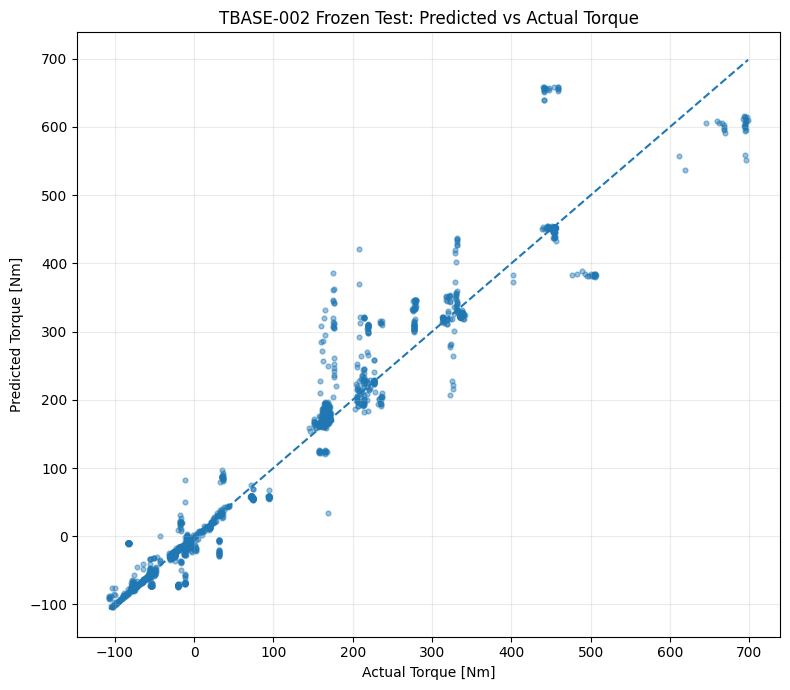

In [13]:
# Step 71.4 — Save final torque diagnostic figures

# ============================================================
# STEP 71.4 — PREDICTED VS ACTUAL TORQUE
# ============================================================

import matplotlib.pyplot as plt

TORQUE_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "torque"
)

TORQUE_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)


ax.scatter(
    tbase002_test_results[
        "actual_torque_nm"
    ],
    tbase002_test_results[
        "predicted_torque_nm"
    ],
    s=12,
    alpha=0.45,
)


axis_min = min(
    tbase002_test_results[
        "actual_torque_nm"
    ].min(),

    tbase002_test_results[
        "predicted_torque_nm"
    ].min(),
)


axis_max = max(
    tbase002_test_results[
        "actual_torque_nm"
    ].max(),

    tbase002_test_results[
        "predicted_torque_nm"
    ].max(),
)


ax.plot(
    [
        axis_min,
        axis_max,
    ],
    [
        axis_min,
        axis_max,
    ],
    linestyle="--",
)


ax.set_xlabel(
    "Actual Torque [Nm]"
)

ax.set_ylabel(
    "Predicted Torque [Nm]"
)

ax.set_title(
    "TBASE-002 Frozen Test: Predicted vs Actual Torque"
)

ax.grid(
    True,
    alpha=0.25,
)


fig.tight_layout()


TBASE002_PVA_PATH = (
    TORQUE_FIGURE_DIR
    / "03_tbase002_test_predicted_vs_actual_v001.png"
)


fig.savefig(
    TBASE002_PVA_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [14]:
# Step 72 — Freeze the final torque benchmark

# Step 72.1 — Update the existing record to show test completion

# ============================================================
# STEP 72.1 — FREEZE FINAL TORQUE BASELINE RECORD
# ============================================================

with open(
    TORQUE_BASELINE_RECORD_PATH,
    "r",
    encoding="utf-8",
) as file:

    final_torque_record = yaml.safe_load(
        file
    )


final_torque_record[
    "test_evaluated"
] = True


final_torque_record[
    "test_metrics"
] = {

    key:
        float(value)

    for key, value
    in tbase002_test_metrics.items()
}


final_torque_record[
    "test_artifacts"
] = {

    "metrics":
        (
            "results/tables/torque/"
            "tbase002_test_metrics_v001.csv"
        ),

    "predictions":
        (
            "results/tables/torque/"
            "tbase002_test_predictions_v001.csv"
        ),
}


with open(
    TORQUE_BASELINE_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        final_torque_record,
        file,
        sort_keys=False,
    )


print(
    "PASS: TBASE-002 final benchmark frozen."
)

PASS: TBASE-002 final benchmark frozen.


In [15]:
# Step 72.2 — Create the final torque report

# ============================================================
# STEP 72.2 — FINAL TORQUE BASELINE REPORT
# ============================================================

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

TORQUE_FINAL_REPORT_PATH = (
    REPORT_DIR
    / "torque_baseline_final_v001.md"
)


validation_metrics = (
    final_torque_record[
        "validation_metrics"
    ]
)


report_text = f"""# Final Torque Baseline — v001

## Population

TORQUE-SPEC-001 contains 11,303 steady-state windows:

- Train: 7,739
- Validation: 1,749
- Test: 1,815

Minimum retention relative to the RPM-steady population was 96.03%.
The split retention spread was 1.24 percentage points.

## Selected model

TBASE-002 — RandomForestRegressor using the frozen 41 FEAT-001
acoustic predictors.

## Validation performance

- MAE: {validation_metrics['mae_nm']:.2f} Nm
- RMSE: {validation_metrics['rmse_nm']:.2f} Nm
- R²: {validation_metrics['r2']:.6f}
- P95 absolute error: {validation_metrics['p95_error_nm']:.2f} Nm

TBASE-002 was selected using validation MAE before the test set was
evaluated.

## Frozen test performance

- MAE: {tbase002_test_metrics['test_mae_nm']:.2f} Nm
- RMSE: {tbase002_test_metrics['test_rmse_nm']:.2f} Nm
- R²: {tbase002_test_metrics['test_r2']:.6f}
- P95 absolute error: {tbase002_test_metrics['test_p95_error_nm']:.2f} Nm

## Status

TBASE-002 is now the frozen conventional torque benchmark.

The test result is final evaluation evidence and will not be used to
tune subsequent models.

## Next phase

RPM and torque will now be modeled jointly using MTL-001.

MTL-001 will be developed and selected using training and validation
data only. Its test split will remain untouched until the multi-task
model-selection decision has been frozen.
"""


TORQUE_FINAL_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{TORQUE_FINAL_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/torque_baseline_final_v001.md


In [ ]:
# Step 73 — Close Notebook 09 cleanly
# Save the notebook directly to GitHub as:
# notebooks/09_torque_target_and_baselines.ipynb
# Then run Step 73.1

